# Визуализация анализа тональности постов

Интерактивный Jupyter notebook для генерации всех графиков анализа тональности Telegram-постов по делу Ларисы Долины.

**Функции:**
- Временные ряды активности и тональности
- Взвешенный индекс S(t) с маркерами событий
- Тепловые карты по каналам и месяцам
- Расхождение гос. vs общ. каналов
- Матрицы ошибок классификаторов
- Анализ влияния событий

**Выход:** PNG графики сохраняются в `results/figures/`

In [123]:
import os
from pathlib import Path

# Определяем корневую папку проекта (ищем папку с config/)
current = Path.cwd()
while current != current.parent:
    if (current / "config").exists() and (current / "vizualization").exists():
        project_root = current
        break
    current = current.parent
else:
    # Fallback: если не найдена папка config, идём на 2 уровня выше (из vizualization/)
    project_root = Path.cwd().parent.parent

os.chdir(project_root)
print(f"✓ Рабочая папка: {project_root.name}/")

✓ Рабочая папка: Algorithm/


In [124]:
import sys
from pathlib import Path

# Добавляем корневую папку проекта в sys.path
project_root = Path.cwd()
if "vizualization" in str(project_root):
    project_root = project_root.parent.parent
sys.path.insert(0, str(project_root))

import argparse
import logging
import json
from IPython.display import Image, display

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [125]:
from config.settings import (
    COLOR_NEGATIVE,
    COLOR_NEUTRAL,
    COLOR_POSITIVE,
    COLOR_PUBLIC,
    COLOR_STATE,
    EVENTS,
    FIGURE_DPI,
    FIGURES_DIR,
    FIGURE_SIZE_WIDE,
    RESULTS_DIR,
    METRICS_JSON,
)

In [126]:
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.dpi":        FIGURE_DPI,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
})

sns.set_theme(style="whitegrid", context="notebook", palette="muted")

# Минимальное количество постов/комментариев для надежного индекса тональности
MIN_COUNT_THRESHOLD = 200

log = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)

In [127]:
def _add_event_markers(
    ax: plt.Axes,
    events: list[dict] = EVENTS,
    ymin: float = 0.0,
    ymax: float = 1.0,
    color: str = "#e67e22",
    alpha: float = 0.7,
) -> None:
    """Добавляет вертикальные линии для ключевых событий на график."""
    for ev in events:
        x = pd.Timestamp(ev["date"], tz="UTC")
        ax.axvline(x=x, color=color, linestyle="--", linewidth=1.0, alpha=alpha)
        ax.text(
            x, ymax * 0.97,
            ev["short"],
            rotation=90,
            fontsize=7,
            color=color,
            alpha=0.85,
            va="top",
            ha="right",
            bbox={
                "boxstyle": "round,pad=0.15",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.65,
            },
        )


def _save(fig: plt.Figure, name: str, show: bool = False) -> Path:
    """Сохраняет фигуру в PNG файл и отображает её в ноутбуке."""
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURES_DIR / f"{name}.png"
    bbox_inches = None if fig.get_constrained_layout() else "tight"
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches=bbox_inches)
    log.info("График сохранён → %s", path)
    plt.close(fig)
    # Отображаем график в ноутбуке
    display(Image(filename=str(path)))
    return path

## 1. Динамика активности постов

15:16:49  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_2_1_activity_timeline.png


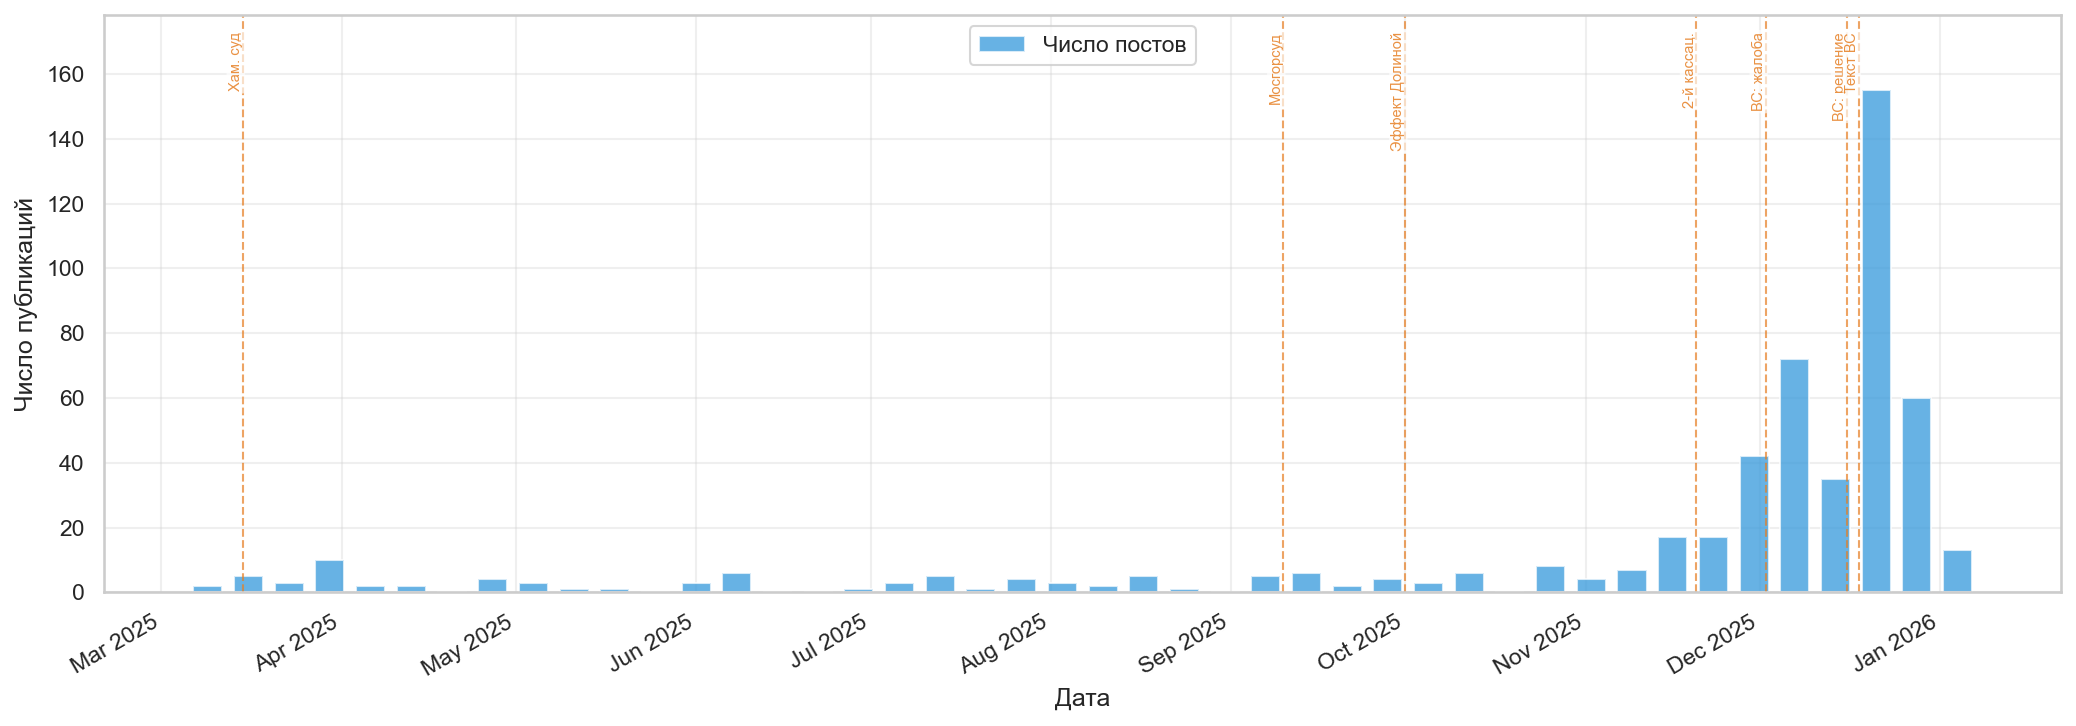

In [128]:
def plot_activity_timeline(df: pd.DataFrame, show: bool = False) -> Path:
    """График: количество постов по неделям."""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE_WIDE)
    df2 = df.copy()
    df2["period"] = pd.to_datetime(df2["period"])

    ax.bar(df2["period"], df2["n_posts"],
           width=5, color="#3498db", alpha=0.75, label="Число постов")
    ax.set_xlabel("Дата")
    ax.set_ylabel("Число публикаций")

    y_max = df2["n_posts"].max() * 1.15
    _add_event_markers(ax, ymax=y_max)
    ax.set_ylim(0, y_max)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=30, ha="right")
    ax.legend()
    fig.tight_layout()
    return _save(fig, "fig_2_1_activity_timeline", show)

# Загружаем данные
df_act = pd.read_csv(RESULTS_DIR / "activity_weekly.csv")
plot_activity_timeline(df_act)
plt.show()

## 2. Динамика распределения тональности

15:16:49  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_2_2_sentiment_timeline.png


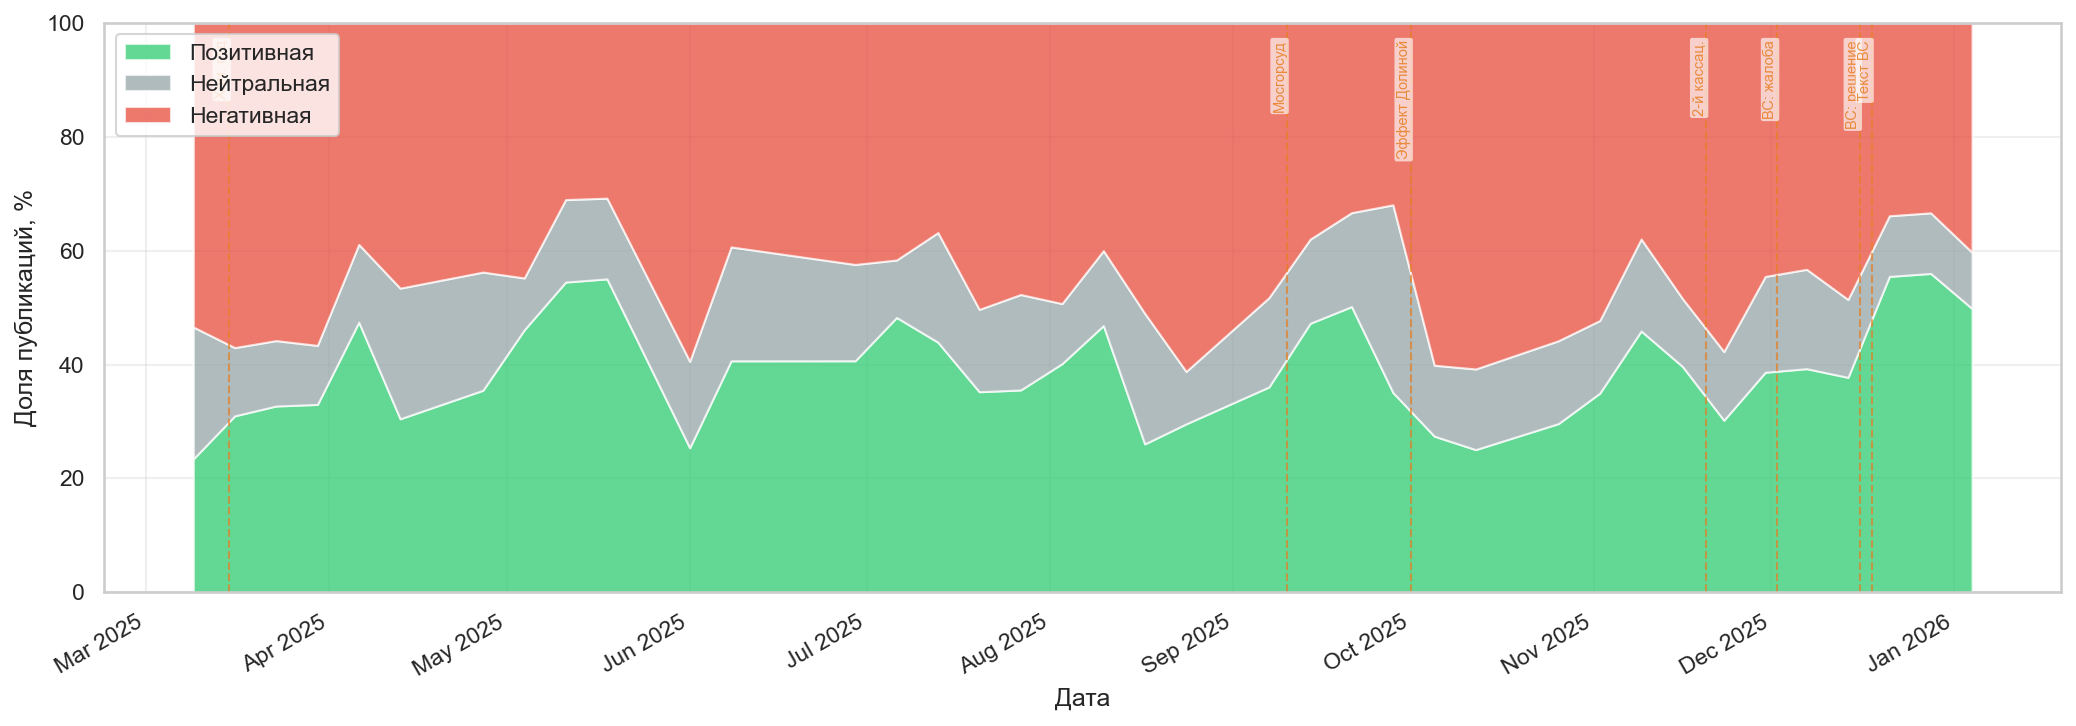

PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_2_2_sentiment_timeline.png')

In [129]:
def plot_sentiment_timeline(df: pd.DataFrame, show: bool = False) -> Path:
    """График: доля каждого класса тональности (stacked area) по неделям."""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE_WIDE)

    df2 = df.copy()
    df2["period"] = pd.to_datetime(df2["period"])
    df2 = df2.sort_values("period")

    ax.stackplot(
        df2["period"],
        df2["pct_positive"],
        df2["pct_neutral"],
        df2["pct_negative"],
        labels=["Позитивная", "Нейтральная", "Негативная"],
        colors=[COLOR_POSITIVE, COLOR_NEUTRAL, COLOR_NEGATIVE],
        alpha=0.75,
    )

    _add_event_markers(ax, ymax=100)
    ax.set_xlabel("Дата")
    ax.set_ylabel("Доля публикаций, %")
    ax.set_ylim(0, 100)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=30, ha="right")
    ax.legend(loc="upper left")
    fig.tight_layout()
    return _save(fig, "fig_2_2_sentiment_timeline", show)

# Загружаем и визуализируем
df_sent = pd.read_csv(RESULTS_DIR / "sentiment_weekly.csv")
plot_sentiment_timeline(df_sent)

## 3. Взвешенный индекс тональности S(t)

15:16:49  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_2_3_sentiment_index.png


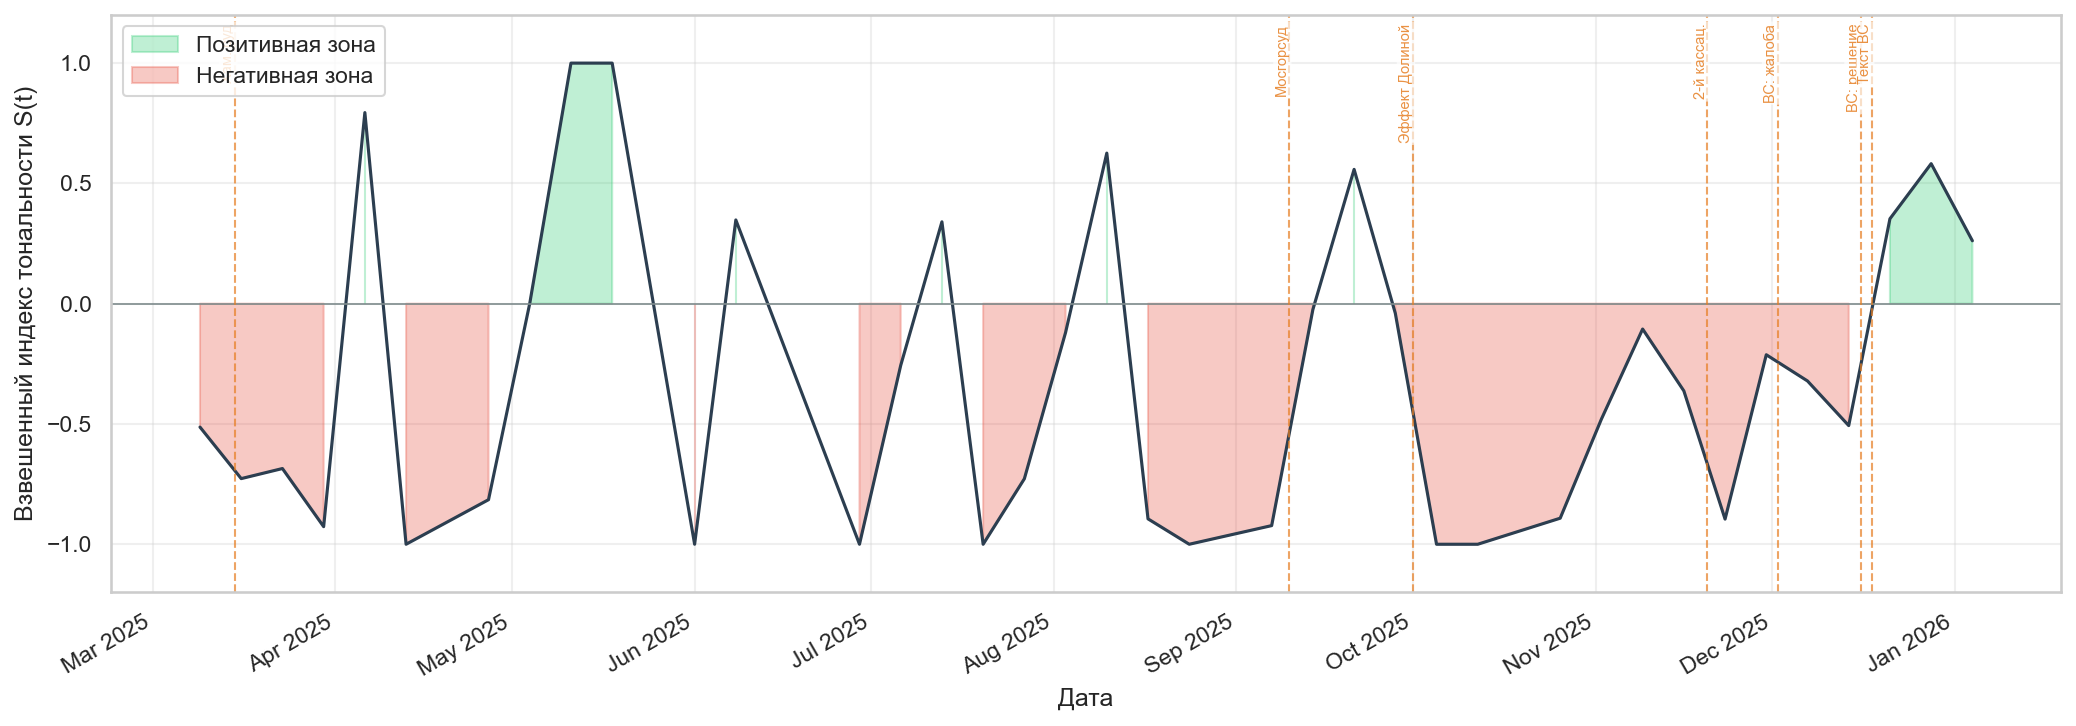

PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_2_3_sentiment_index.png')

In [130]:
def plot_sentiment_index(df: pd.DataFrame, show: bool = False) -> Path:
    """График: взвешенный индекс S(t) с заливкой по зонам."""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE_WIDE)

    df2 = df.copy()
    df2["period"] = pd.to_datetime(df2["period"])
    df2 = df2.sort_values("period")

    periods = df2["period"].values
    si = df2["weighted_si"].values

    ax.fill_between(periods, si, 0,
                    where=(si >= 0),
                    alpha=0.3, color=COLOR_POSITIVE, label="Позитивная зона")
    ax.fill_between(periods, si, 0,
                    where=(si < 0),
                    alpha=0.3, color=COLOR_NEGATIVE, label="Негативная зона")
    ax.plot(periods, si, color="#2c3e50", linewidth=1.5)
    ax.axhline(0, color="#7f8c8d", linewidth=0.8, linestyle="-")

    y_abs = max(abs(si).max() * 1.2, 0.1)
    _add_event_markers(ax, ymin=-y_abs, ymax=y_abs)
    ax.set_ylim(-y_abs, y_abs)
    ax.set_xlabel("Дата")
    ax.set_ylabel("Взвешенный индекс тональности S(t)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=30, ha="right")
    ax.legend(loc="upper left")
    fig.tight_layout()
    return _save(fig, "fig_2_3_sentiment_index", show)

# Загружаем и визуализируем
df_agg = pd.read_csv(RESULTS_DIR / "agg_by_period_weekly.csv")
plot_sentiment_index(df_agg)

## 4. Тепловая карта тональности по каналам

15:16:49  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_2_4_channel_heatmap.png


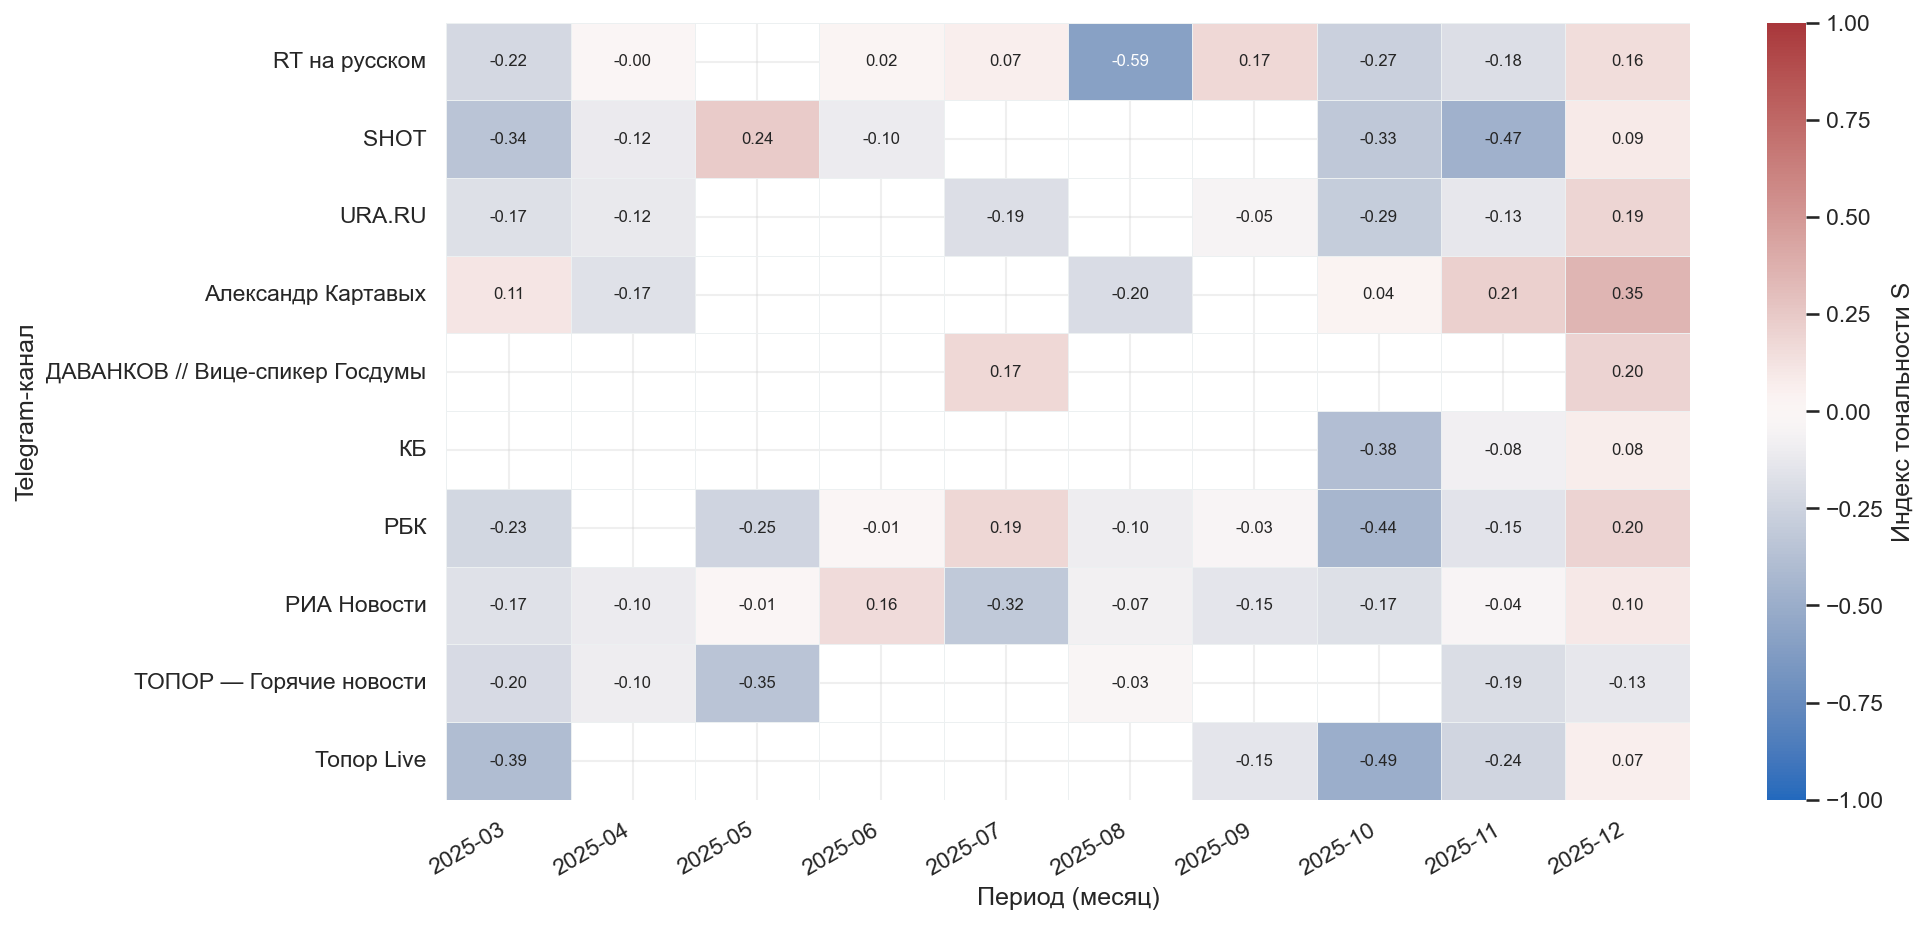

PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_2_4_channel_heatmap.png')

In [131]:
def plot_channel_heatmap(df_wide: pd.DataFrame, show: bool = False) -> Path:
    """Тепловая карта: индекс S(t) по каналам и месяцам."""
    fig, ax = plt.subplots(figsize=(14, 7))

    sns.heatmap(
        df_wide.T,
        ax=ax,
        cmap="vlag",
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.4,
        linecolor="#ecf0f1",
        annot=True,
        fmt=".2f",
        annot_kws={"fontsize": 8},
        cbar_kws={"label": "Индекс тональности S"},
    )
    ax.set_xlabel("Период (месяц)")
    ax.set_ylabel("Telegram-канал")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    fig.subplots_adjust(bottom=0.18, left=0.22, right=0.96, top=0.92)
    return _save(fig, "fig_2_4_channel_heatmap", show)

# Загружаем и визуализируем
df_ch = pd.read_csv(RESULTS_DIR / "channel_comparison.csv")
df_ch = df_ch.set_index(df_ch.columns[0])
plot_channel_heatmap(df_ch)

## 5. Расхождение государственных vs общественных каналов

15:16:49  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_2_5_orientation_divergence.png


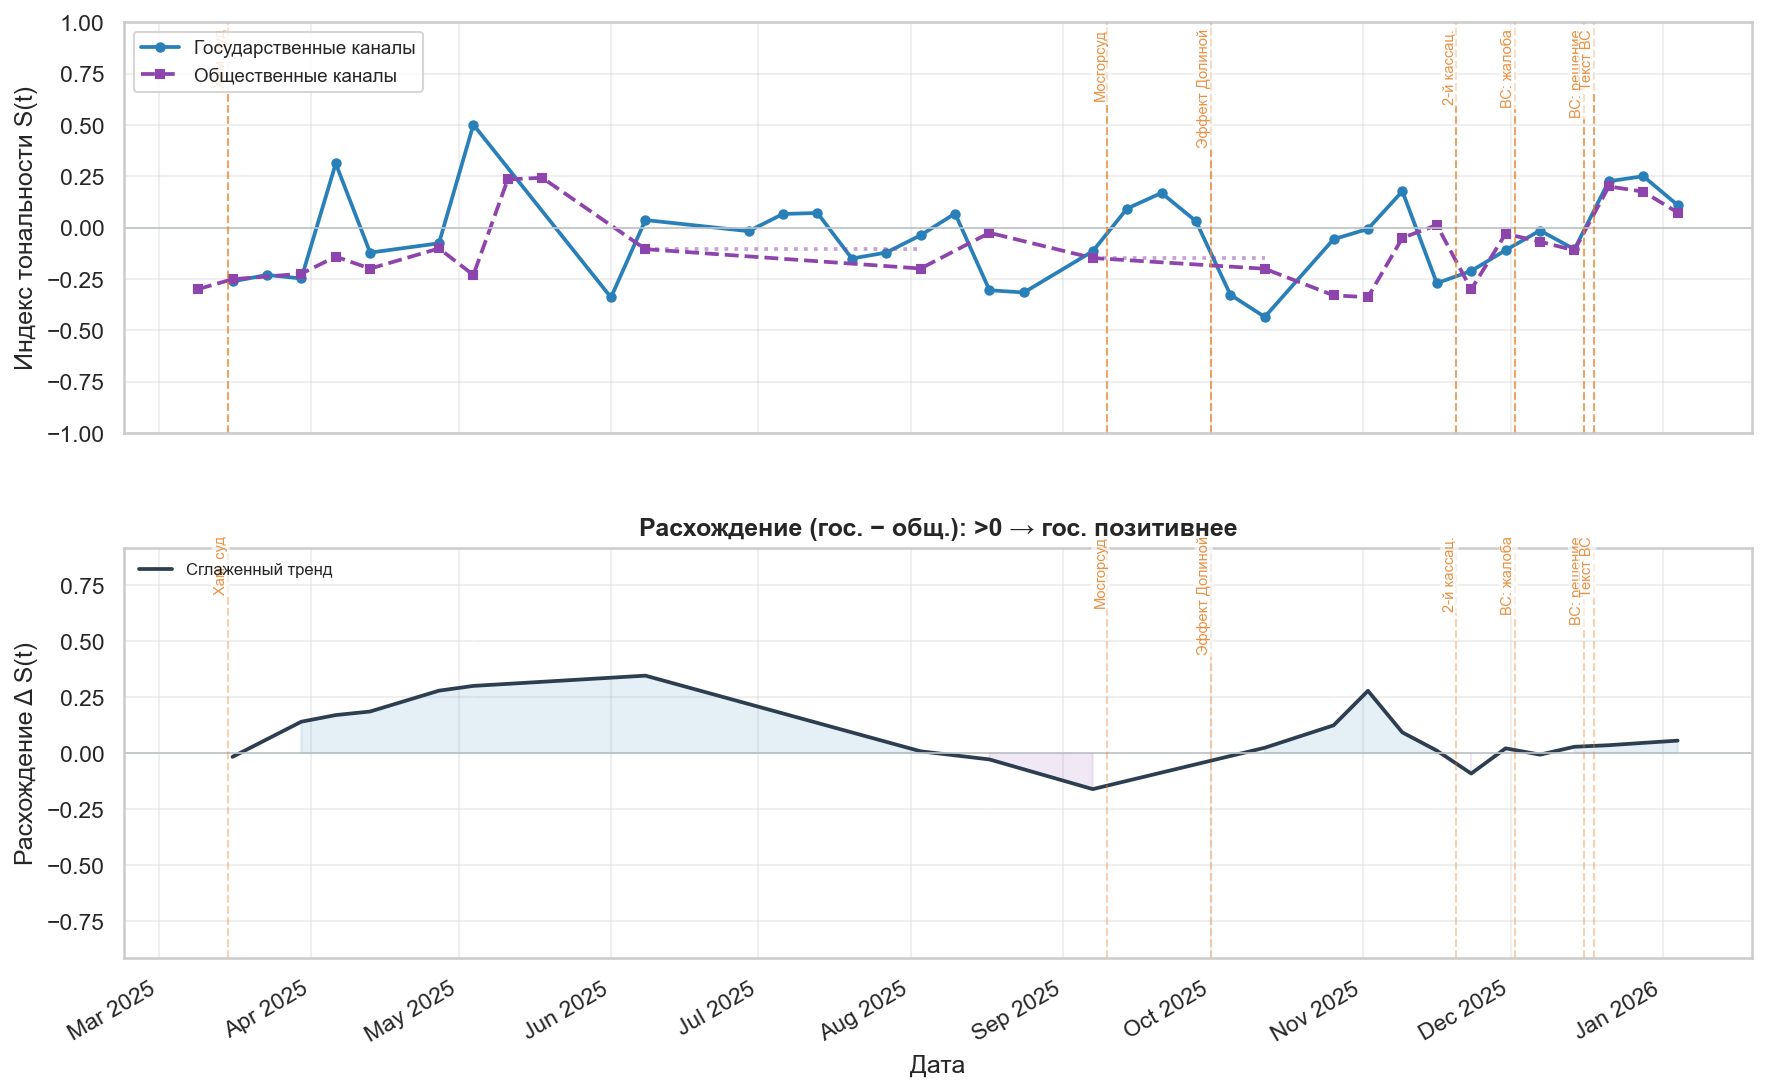

PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_2_5_orientation_divergence.png')

In [132]:
def plot_orientation_divergence(df: pd.DataFrame, show: bool = False) -> Path:
    """График: S(t) по ориентации и расхождение (гос. - общ.)."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    df2 = df.copy()
    df2["period"] = pd.to_datetime(df2["period"])
    df2 = df2.sort_values("period")
    periods = df2["period"].values
    
    # Определяем ненадежные периоды (малое количество данных)
    n_state = df2.get("n_state", pd.Series(dtype=float)).values
    n_public = df2.get("n_public", pd.Series(dtype=float)).values
    
    # Если данных о количестве нет — не применяем затенение
    if len(n_state) > 0 and len(n_public) > 0:
        n_state = np.full_like(periods, 0, dtype=float) if len(n_state) == 0 else n_state
        n_public = np.full_like(periods, 0, dtype=float) if len(n_public) == 0 else n_public
        sparse_mask = (n_state < MIN_COUNT_THRESHOLD) | (n_public < MIN_COUNT_THRESHOLD)
        
        # Затеняем ненадежные периоды
        for i in range(len(periods) - 1):
            if sparse_mask[i]:
                ax1.axvspan(periods[i], periods[i+1], alpha=0.08, color="gray")
                ax2.axvspan(periods[i], periods[i+1], alpha=0.08, color="gray")

    # Соединяем разорванные линии горизонтальными отрезками
    if df2["state_index"].notna().any():
        valid_state = df2[df2["state_index"].notna()].copy()
        ax1.plot(valid_state["period"], valid_state["state_index"], 
                 color=COLOR_STATE, linewidth=1.8, label="Государственные каналы", marker="o", markersize=4)
        
        for i in range(len(valid_state) - 1):
            curr_date = valid_state.iloc[i]["period"]
            next_date = valid_state.iloc[i+1]["period"]
            curr_idx = valid_state.iloc[i]["state_index"]
            
            date_diff = (next_date - curr_date).days
            if date_diff > 32:
                ax1.plot([curr_date, next_date], [curr_idx, curr_idx], 
                        color=COLOR_STATE, linewidth=1.8, alpha=0.5, linestyle=":")
    
    if df2["public_index"].notna().any():
        valid_public = df2[df2["public_index"].notna()].copy()
        ax1.plot(valid_public["period"], valid_public["public_index"], 
                 color=COLOR_PUBLIC, linewidth=1.8, linestyle="--", label="Общественные каналы", marker="s", markersize=4)
        
        for i in range(len(valid_public) - 1):
            curr_date = valid_public.iloc[i]["period"]
            next_date = valid_public.iloc[i+1]["period"]
            curr_idx = valid_public.iloc[i]["public_index"]
            
            date_diff = (next_date - curr_date).days
            if date_diff > 32:
                ax1.plot([curr_date, next_date], [curr_idx, curr_idx], 
                        color=COLOR_PUBLIC, linewidth=1.8, alpha=0.5, linestyle=":")
    
    ax1.axhline(0, color="#bdc3c7", linewidth=0.8)
    ax1.set_ylabel("Индекс тональности S(t)")
    ax1.set_ylim(-1.0, 1.0)
    _add_event_markers(ax1, ymax=1.0)
    
    from matplotlib.patches import Patch
    handles, labels = ax1.get_legend_handles_labels()
    if "n_state" in df2.columns and "n_public" in df2.columns:
        sparse_patch = Patch(facecolor="gray", alpha=0.08, label="Малое количество данных (n<200)")
        ax1.legend(handles + [sparse_patch], labels + ["Малое количество данных (n<200)"], loc="upper left", fontsize=9)
    else:
        ax1.legend(handles, labels, loc="upper left", fontsize=9)

    valid_div = df2.dropna(subset=["divergence"])
    if valid_div.empty:
        ax2.axis("off")
        ax2.text(0.5, 0.5, "Недостаточно данных для расчёта расхождения",
                ha="center", va="center", fontsize=10,)
    else:
        div_periods = pd.to_datetime(valid_div["period"]).values
        divergence = valid_div["divergence"].values
        divergence_series = pd.Series(divergence, index=div_periods)
        smooth = divergence_series.rolling(window=3, center=True, min_periods=1).mean().values

        ax2.bar(div_periods, divergence, width=5,
                color=[COLOR_STATE if d >= 0 else COLOR_PUBLIC for d in divergence],
                alpha=0.25)
        ax2.plot(div_periods, smooth, color="#2c3e50", linewidth=1.8, label="Сглаженный тренд")
        ax2.fill_between(div_periods, smooth, 0, where=(smooth >= 0),
                         color=COLOR_STATE, alpha=0.12)
        ax2.fill_between(div_periods, smooth, 0, where=(smooth < 0),
                         color=COLOR_PUBLIC, alpha=0.12)
        ax2.axhline(0, color="#bdc3c7", linewidth=0.8)
        ax2.set_xlabel("Дата")
        ax2.set_ylabel("Расхождение Δ S(t)")
        ax2.set_title("Расхождение (гос. − общ.): >0 → гос. позитивнее")
        _add_event_markers(ax2, alpha=0.35)
        ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
        ax2.xaxis.set_major_locator(mdates.MonthLocator())
        plt.xticks(rotation=30, ha="right")
        ax2.legend(loc="upper left", fontsize=8, frameon=False)
        max_abs = float(np.nanmax(np.abs(divergence))) if len(divergence) else 0.1
        ax2.set_ylim(-max_abs * 1.25 if max_abs > 0 else -0.1, max_abs * 1.25 if max_abs > 0 else 0.1)
    
    fig.subplots_adjust(hspace=0.28, bottom=0.14, top=0.92)
    return _save(fig, "fig_2_5_orientation_divergence", show)

# Загружаем и визуализируем
df_div = pd.read_csv(RESULTS_DIR / "orientation_divergence.csv")
plot_orientation_divergence(df_div)

## 6. Матрицы ошибок классификаторов

15:16:49  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_2_6_confusion_matrix_logreg.png


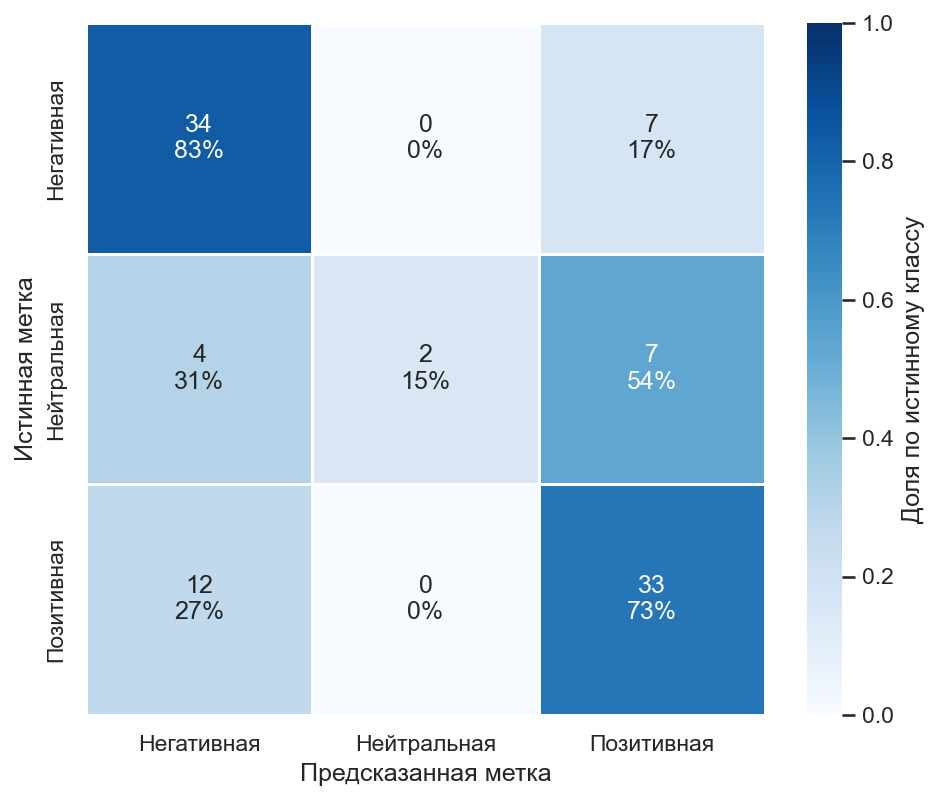

15:16:49  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_2_6_confusion_matrix_svm.png


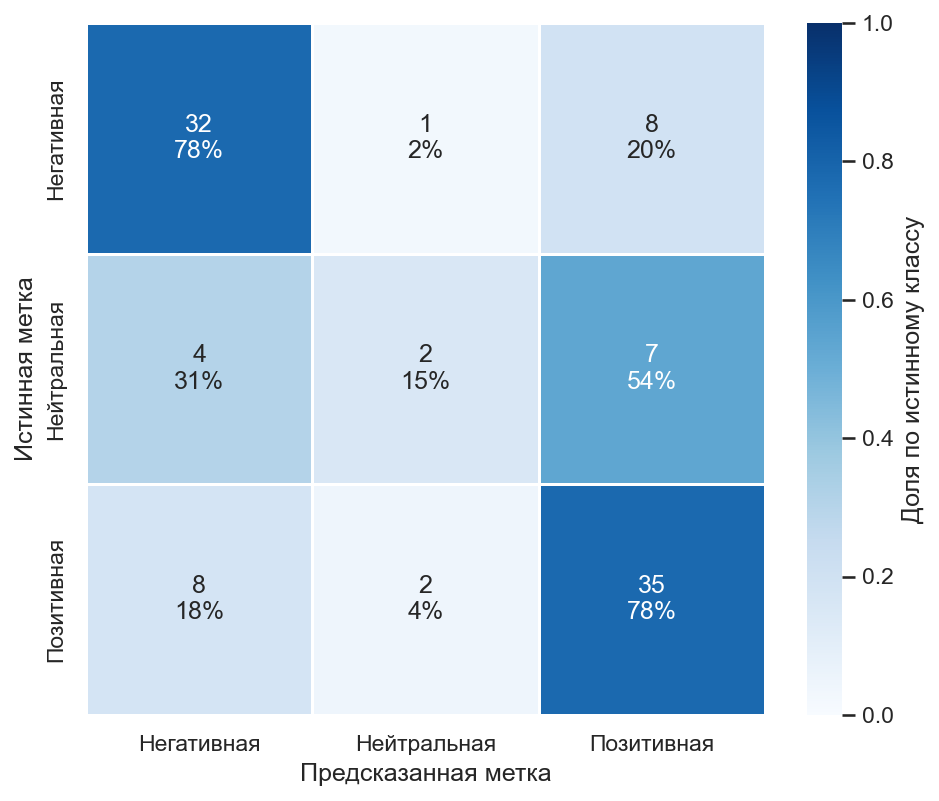

In [133]:
def plot_confusion_matrix(cm: list[list[int]], model_name: str = "logreg",
                          labels: list[str] | None = None, show: bool = False) -> Path:
    """Матрица ошибок классификатора (нормализованная)."""
    if labels is None:
        labels = ["Негативная", "Нейтральная", "Позитивная"]

    cm_arr = np.array(cm)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))

    row_sums = cm_arr.sum(axis=1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_pct = np.divide(
            cm_arr,
            row_sums,
            out=np.zeros_like(cm_arr, dtype=float),
            where=row_sums != 0,
        )

    annot = np.empty_like(cm_arr, dtype=object)
    for i in range(cm_arr.shape[0]):
        for j in range(cm_arr.shape[1]):
            count = cm_arr[i, j]
            pct = cm_pct[i, j]
            annot[i, j] = f"{count}\n{pct:.0%}"

    sns.heatmap(cm_pct, ax=ax, annot=annot, fmt="",
                cmap="Blues", vmin=0, vmax=1,
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, cbar=True,
                cbar_kws={"label": "Доля по истинному классу"})
    ax.set_xlabel("Предсказанная метка")
    ax.set_ylabel("Истинная метка")
    fig.tight_layout()
    return _save(fig, f"fig_2_6_confusion_matrix_{model_name}", show)

# Загружаем метрики
if METRICS_JSON.exists():
    with open(METRICS_JSON, encoding="utf-8") as f:
        metrics_data = json.load(f)
    
    for model_name in ["logreg", "svm"]:
        cm = metrics_data.get(model_name, {}).get("confusion_matrix")
        if cm:
            plot_confusion_matrix(cm, model_name)

## 7. Сравнение моделей

15:16:49  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_2_7_model_comparison.png


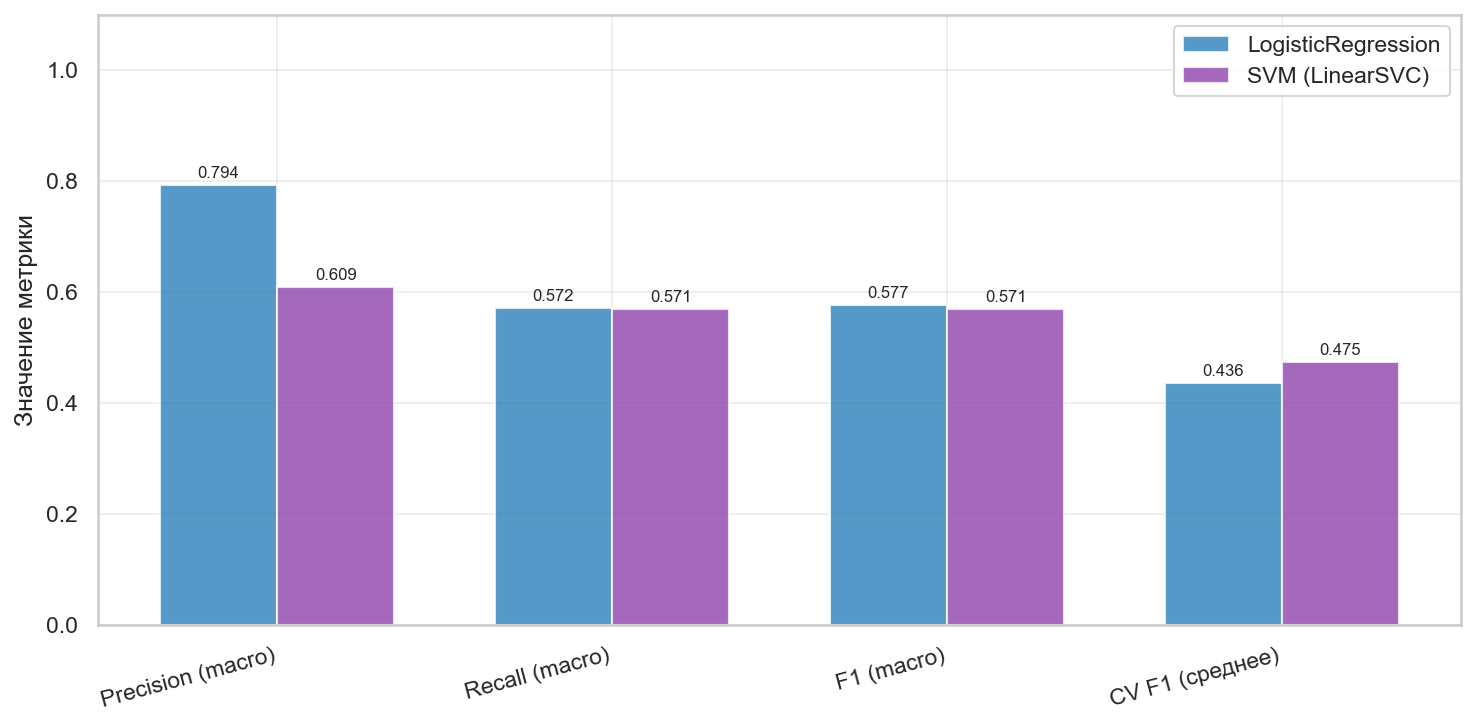

In [134]:
def plot_model_comparison(compare_df: pd.DataFrame, show: bool = False) -> Path:
    """Сравнение метрик LogisticRegression vs SVM."""
    metrics_to_plot = [
        "Precision (macro)", "Recall (macro)", "F1 (macro)", "CV F1 (среднее)"
    ]
    metric_col = "Метрика" if "Метрика" in compare_df.columns else "metric"
    logreg_col = "LogReg" if "LogReg" in compare_df.columns else "logreg"
    svm_col = "SVM" if "SVM" in compare_df.columns else "svm"

    label_map = {
        "precision_macro": "Precision (macro)",
        "recall_macro": "Recall (macro)",
        "f1_macro": "F1 (macro)",
        "cv_f1_mean": "CV F1 (среднее)",
    }

    sub = compare_df.copy()
    sub[metric_col] = sub[metric_col].replace(label_map)
    sub = sub[sub[metric_col].isin(metrics_to_plot)].copy()

    x = np.arange(len(sub))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    lr_vals = pd.to_numeric(sub[logreg_col], errors="coerce").values
    svm_vals = pd.to_numeric(sub[svm_col], errors="coerce").values

    bars1 = ax.bar(x - width / 2, lr_vals, width, label="LogisticRegression",
                   color=COLOR_STATE, alpha=0.8)
    bars2 = ax.bar(x + width / 2, svm_vals, width, label="SVM (LinearSVC)",
                   color=COLOR_PUBLIC, alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(sub[metric_col].values, rotation=15, ha="right")
    ax.set_ylim(0, max(1.1, float(np.nanmax([lr_vals, svm_vals])) * 1.15))
    ax.set_ylabel("Значение метрики")
    ax.legend()
    ax.bar_label(bars1, fmt="%.3f", fontsize=8, padding=2)
    ax.bar_label(bars2, fmt="%.3f", fontsize=8, padding=2)
    fig.tight_layout()
    return _save(fig, "fig_2_7_model_comparison", show)

# Загружаем сравнение
try:
    from models.svm_clf import comparison_table
    cmp_df = comparison_table()
    plot_model_comparison(cmp_df)
except Exception as exc:
    log.warning("Не удалось построить сравнение моделей: %s", exc)

## 8. Влияние ключевых событий на тональность

15:16:49  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_2_8_event_impact.png


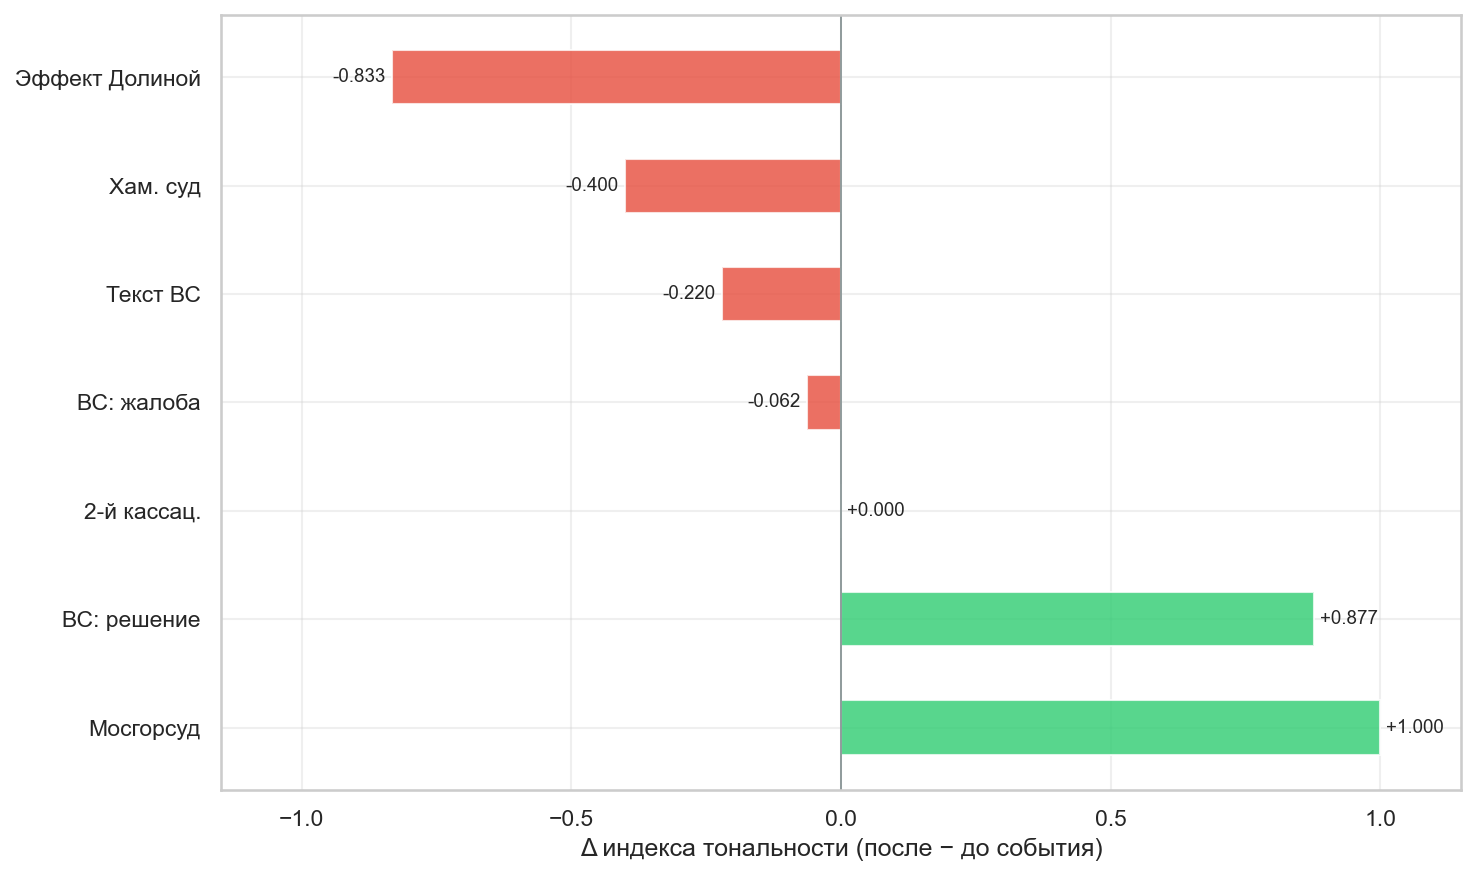

PosixPath('/Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/fig_2_8_event_impact.png')

In [135]:
def plot_event_impact(df: pd.DataFrame, show: bool = False) -> Path:
    """График: δ тональности (±7 дней вокруг событий)."""
    df2 = df.dropna(subset=["delta"]).copy()
    df2 = df2.sort_values("delta")

    fig, ax = plt.subplots(figsize=(10, 6))

    if df2.empty:
        ax.axis("off")
        ax.text(0.5, 0.5, "Нет данных для оценки влияния событий",
                ha="center", va="center", fontsize=11,)
        return _save(fig, "fig_2_8_event_impact", show)

    if np.allclose(df2["delta"].values, 0):
        labels = df2["event_label"].astype(str)
        if "n_before" in df2.columns and "n_after" in df2.columns:
            labels = labels + " (n=" + df2["n_before"].astype(int).astype(str) + "/" + df2["n_after"].astype(int).astype(str) + ")"
        y_pos = np.arange(len(df2))
        ax.scatter(np.zeros(len(df2)), y_pos, s=60, color="#7f8c8d", alpha=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels)
        ax.axvline(0, color="#7f8c8d", linewidth=0.8)
        ax.set_xlim(-0.1, 0.1)
        ax.set_xlabel("Δ индекса тональности (после − до события)")
        ax.set_title("Изменение тональности дискуссии\nв ±7 дней вокруг ключевых событий")
        ax.invert_yaxis()
        ax.grid(axis="x", alpha=0.3)
        fig.tight_layout()
        return _save(fig, "fig_2_8_event_impact", show)

    colors = [COLOR_POSITIVE if d >= 0 else COLOR_NEGATIVE for d in df2["delta"]]
    bars = ax.barh(df2["event_label"], df2["delta"],
                   color=colors, alpha=0.8, height=0.5)
    ax.axvline(0, color="#7f8c8d", linewidth=0.8)
    ax.bar_label(bars, fmt="%+.3f", fontsize=9, padding=3)
    ax.set_xlabel("Δ индекса тональности (после − до события)")
    ax.invert_yaxis()
    max_abs = float(np.nanmax(np.abs(df2["delta"])))
    ax.set_xlim(-max_abs * 1.15 if max_abs > 0 else -0.1, max_abs * 1.15 if max_abs > 0 else 0.1)
    fig.tight_layout()
    return _save(fig, "fig_2_8_event_impact", show)

# Загружаем и визуализируем
df_impact = pd.read_csv(RESULTS_DIR / "event_impact.csv")
plot_event_impact(df_impact)

## Запуск всех графиков одной командой

In [136]:
def generate_all_plots() -> list[Path]:
    """Генерирует все графики и сохраняет в PNG."""
    saved = []
    
    # 1. Активность
    try:
        df_act = pd.read_csv(RESULTS_DIR / "activity_weekly.csv")
        saved.append(plot_activity_timeline(df_act))
    except Exception as e:
        log.error("Ошибка при графике активности: %s", e)
    
    # 2. Распределение тональности
    try:
        df_sent = pd.read_csv(RESULTS_DIR / "sentiment_weekly.csv")
        saved.append(plot_sentiment_timeline(df_sent))
    except Exception as e:
        log.error("Ошибка при графике тональности: %s", e)
    
    # 3. Индекс S(t)
    try:
        df_agg = pd.read_csv(RESULTS_DIR / "agg_by_period_weekly.csv")
        saved.append(plot_sentiment_index(df_agg))
    except Exception as e:
        log.error("Ошибка при графике индекса: %s", e)
    
    # 4. Тепловая карта
    try:
        df_ch = pd.read_csv(RESULTS_DIR / "channel_comparison.csv")
        df_ch = df_ch.set_index(df_ch.columns[0])
        saved.append(plot_channel_heatmap(df_ch))
    except Exception as e:
        log.error("Ошибка при графике тепловой карты: %s", e)
    
    # 5. Расхождение ориентаций
    try:
        df_div = pd.read_csv(RESULTS_DIR / "orientation_divergence.csv")
        saved.append(plot_orientation_divergence(df_div))
    except Exception as e:
        log.error("Ошибка при графике расхождения: %s", e)
    
    # 6-7. Матрицы ошибок
    try:
        if METRICS_JSON.exists():
            with open(METRICS_JSON, encoding="utf-8") as f:
                metrics_data = json.load(f)
            
            for model_name in ["logreg", "svm"]:
                cm = metrics_data.get(model_name, {}).get("confusion_matrix")
                if cm:
                    saved.append(plot_confusion_matrix(cm, model_name))
    except Exception as e:
        log.error("Ошибка при матрицах ошибок: %s", e)
    
    # 7. Сравнение моделей
    try:
        from models.svm_clf import comparison_table
        cmp_df = comparison_table()
        saved.append(plot_model_comparison(cmp_df))
    except Exception as e:
        log.warning("Не удалось построить сравнение моделей: %s", e)
    
    # 8. Влияние событий
    try:
        df_impact = pd.read_csv(RESULTS_DIR / "event_impact.csv")
        saved.append(plot_event_impact(df_impact))
    except Exception as e:
        log.error("Ошибка при графике событий: %s", e)
    
    return saved

print(f"\n✓ Готово! Сохранено {len(paths)} графиков в {FIGURES_DIR}")


✓ Готово! Сохранено 9 графиков в /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures
